In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
load_dotenv("../.env")
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
DATASET_PATH=os.path.join("/home/david/Downloads/ragnnarok_datasets/")
# DATASET_PATH=os.path.join("/home/david/Downloads/IcaRAus_datasets/")
# MODEL_TRAINING_DATASET_PATH="/home/david/Downloads/ragnnarok_datasets/"
# GENERATED_DATASETS_PATH=os.getenv("GENERATED_DATASETS_PATH")
# GENERATED_DATASETS_PATH="/home/david/Downloads/ragnnarok_datasets/RaGNNarok_ugv_RaGNNarok_ds_wilk_basement_train"

sys.path.append("../")
from cpsl_datasets.gnn_node_ds import GnnNodeDS

from mmwave_model_integrator.input_encoders._node_encoder import _NodeEncoder
from mmwave_model_integrator.ground_truth_encoders._gt_node_encoder import _GTNodeEncoder
from mmwave_model_integrator.plotting.plotter_gnn_pc_processing import PlotterGnnPCProcessing


/home/david/.cache/pypoetry/virtualenvs/odometry-JJ4jnFPp-py3.12/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
#initialize the dataset
config_label = "RaGNNarok_final_RaGNNarok_ds"
# config_label = "RaGNNarok_final_IcaRAus_ds"

dataset_label = "RaGNNarok_ugv_RaGNNarok_ds_wilk_basement"
# dataset_label = "RaGNNarok_ugv_IcaRAus_ds_wilk_cpsl_north"
dataset_path = os.path.join(DATASET_PATH,"{}_train".format(dataset_label))
dataset = GnnNodeDS(
    dataset_path=dataset_path,
    node_folder="nodes",
    label_folder="labels"
)
print(dataset_path)

found 7201 input samples
found 7201 label samples
/home/david/Downloads/ragnnarok_datasets/RaGNNarok_ugv_RaGNNarok_ds_wilk_basement_train


In [3]:
#initialize the encoder and decoder
input_encoder = _NodeEncoder()
ground_truth_encoder = _GTNodeEncoder()
plotter = PlotterGnnPCProcessing()

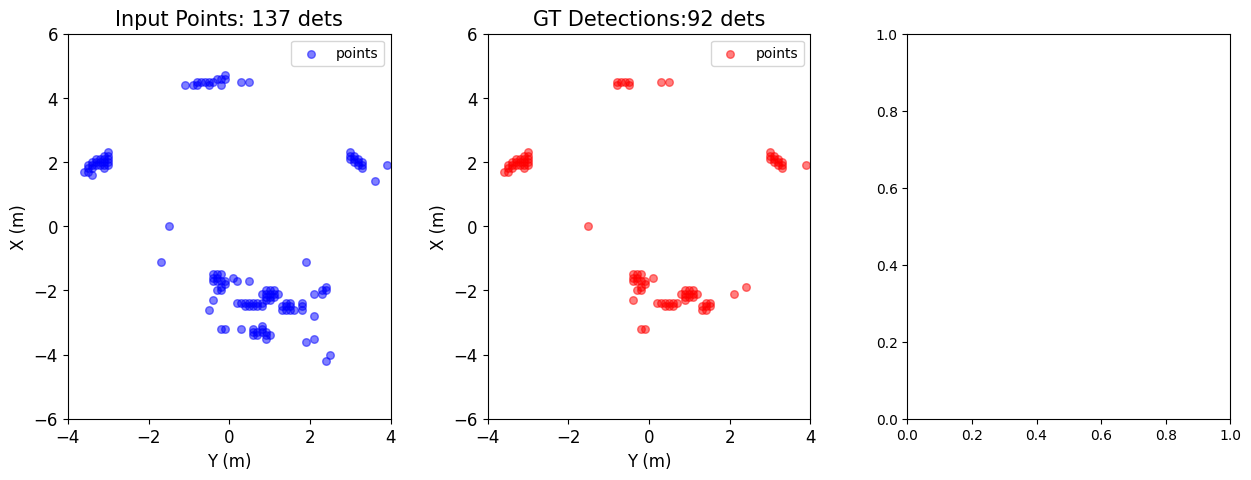

In [4]:
#plot a sample from the training dataset
idx=600
nodes = dataset.get_node_data(idx=idx)
labels = dataset.get_label_data(idx=idx)

plotter.plot_compilation(
    input_data=nodes,
    gt_data=labels,
    input_encoder=input_encoder,
    ground_truth_encoder=ground_truth_encoder,
    show=True
)

In [5]:
from mmwave_model_integrator.config import Config
import mmwave_model_integrator.torch_training.trainers as trainers

config_path = "../configs/RaGNNarok/RaGNNarok_final_RaGNNarok_ds.py"
config = Config(config_path)

config.print_config()

trainer_config = config.trainer
trainer_class = getattr(trainers,trainer_config.pop('type'))
trainer = trainer_class(**trainer_config)

model=dict(
    type=SageGNNClassifier,
    in_channels=4,
    hidden_channels=16,
    out_channels=1,
),
config_label=RaGNNarok_final_RaGNNarok_ds,
generated_dataset=dict(
    input_encoding_folder=nodes,
    ground_truth_encoding_folder=labels,
    generated_dataset_path=/home/david/Downloads/ragnnarok_datasets/RaGNNarok_ugv_RaGNNarok_ds_wilk_basement_train,
),
trainer=dict(
    type=GNNTorchTrainer,
    model=dict(
        type=SageGNNClassifier,
        in_channels=4,
        hidden_channels=16,
        out_channels=1,
    ),
    optimizer=dict(
        type=Adam,
        lr=0.001,
    ),
    loss_fn=dict(
        type=BCELoss,
    ),
    dataset=dict(
        type=_GnnNodeDataset,
        edge_radius=10.0,
        transforms=[],
        enable_random_yaw_rotate=True,
        enable_occupancy_grid_preturbations=True,
        enable_x_y_position_preturbations=True,
        enable_cylindrical_encoding=False,
    ),
    data_loader=dict(
        type=TGDataLoader,
        batch_size=2

In [6]:
trainer.train_model()

ModelTrainer.train: training the network...


Epoch:   8%|▊         | 1/13 [00:03<00:43,  3.59s/it]

	 Train loss: 0.6760732446398053, Val loss: 0.731787383556366, Val F1: 0.8114125233380924
EPOCH: 1/13
	 Train loss: 0.6760732446398053, Val loss: 0.731787383556366, Val F1: 0.8114125233380924


Epoch:  15%|█▌        | 2/13 [00:06<00:37,  3.45s/it]

	 Train loss: 0.6608175720487323, Val loss: 0.7262629866600037, Val F1: 0.8114125233380924
EPOCH: 2/13
	 Train loss: 0.6608175720487323, Val loss: 0.7262629866600037, Val F1: 0.8114125233380924


...

	 Train loss: 0.610623075848534, Val loss: 0.6647034883499146, Val F1: 0.8114125233380924
EPOCH: 11/13
	 Train loss: 0.610623075848534, Val loss: 0.6647034883499146, Val F1: 0.8114125233380924


Epoch:  92%|█████████▏| 12/13 [00:30<00:02,  2.35s/it]

	 Train loss: 0.6078651433899289, Val loss: 0.6670046448707581, Val F1: 0.8114125233380924
EPOCH: 12/13
	 Train loss: 0.6078651433899289, Val loss: 0.6670046448707581, Val F1: 0.8114125233380924


	 Train loss: 0.6074749174572173, Val loss: 0.65972900390625, Val F1: 0.8114125233380924
EPOCH: 13/13
	 Train loss: 0.6074749174572173, Val loss: 0.65972900390625, Val F1: 0.8114125233380924
ModelTrainer.train: total training time 32.70


tensor(0.6597, device='cuda:0')